<img src="../Imagens/Cabecalho.png"/>

# <div align="center">Fundamentos da Rede Neural Informada por Física (*Physics Informed Neural Network*, PINN)</div> 

`Autor`: Giulio Oertel Spinelli Roux César

------------------------------

# 1. Objetivo do *notebook*

O objetivo desse *notebook* é introduzir de forma didática os fundamentos da Rede Neural Informada por Física, também conhecida como PINN. Para tanto, analisamos o problema de Resfriamento de Newton, o mais simples possível, através de uma MLP e de uma PINN, montada por partes. 

Lei de Resfriamento de Newton.
$$
\frac{\mathrm d}{\mathrm d t}T(t) =  r\,(T_{amb} - T(t))
$$
Em que $T(t)$ é a temperatura do sistema ao longo do tempo, $r$ é a taxa de resfriamento, $T_{\mathrm{amb}}$ é a temperatura ambiente.

**Conhecimentos prévios:** A fim de compreender o *notebook*, espera-se conhecimentos básicos de Equações Diferenciais (não como resolvê-las, mas estar familiarizado com sua estrutura) e de aprendizado de máquina, bem como contato prévio com `PyTorch`.

**`Importante`**: Este *notebook* acompanha um arquivo auxiliar chamado `funcoes.py` onde estão funções auxiliares, permitindo que o *notebook* seja focado em ensinar sobre PINNs, sem longos desvios.

-------------------------------

# 2. Introdução Teórica

## 2.1 *Multi-Layer Perceptron* (MLP)

Uma MLP, ou *Multi-Layer Perceptron* em inglês, é o tipo mais simples de rede neural. Ela é composta por uma camada de entrada, uma ou mais camadas ocultas e uma camada de saída. Cada camada é composta por uma determinada quantidade de neurônios. A composição de número de camadas e quantidade de neurônios em cada uma é chamada **arquitetura da rede**. Na Figura 1, por exemplo, há uma arquitetura com 1 camada de entrada e 2 camadas ocultas com múltiplos neurônios e 1 camada de saída com dois neurônios. [1-2]

<div align=\"center\">
    <img src="../Imagens/Rede.png"/>
</div>

<div align="center"><b>Figura 1.</b> Ilustração da arquitetura de uma MLP. Fonte: https://franckepeixoto.medium.com/mlp-multilayer-perceptron-conceito-de-b%C3%A1sico-93afa91dd03e </div> <br>

Cada neurônio recebe um *input* com um peso atribuído, aplica uma função qualquer definida ao montar a rede neural, chamada **função de ativação** e soma um viés a isso. O resultado dessa conta é passado adiante para os neurônios da camada seguinte, caracterizando o <b>*feedforward* (propagação direta dos dados)</b>. Essas contas são "guardadas" em um grafo, ele conta a sequência de contas que foi feita pela rede (importante a seguir). Dessa forma, a rede neural pode ser interpretada como uma função. [1-2]

Uma característica importante dessa função (rede neural) é que ela é diferenciável. Com isso, podemos otimizar os valores dos parâmetros internos (pesos e viéses de cada neurônio) utilizando um algoritmo chamado <b>*backpropagation* (retropropagação da perda na saída)</b>. Para tanto, é preciso calular o erro do resultado da rede, o que pode ser feito através de uma **função de perda** (uma métrica que compare o valor verdadeiro com o predito, MSE por exemplo). [1-2]

Com a perda, é possível realizar sua retropropagação pela rede **calculando a derivada** da função de perda em relação aos parâmetros da rede no grafo montado no *forward pass* (passo em que o *feedforward* é implementado). Esse grafo é importante, pois a **derivada é calculada com base na regra da cadeia**, então a ordem exata das contas importa e o **grafo deve ser ordenado topologicamente**. Essas derivadas podem, então, ser utilizadas para dizer a relação entre o parâmetro e a função de perda. Se a derivada for negativa, por exemplo, aumentar o valor do parâmetro diminui a função de perda (o que buscamos na otimização!). [1-2]

Depois de realizar o *forward pass* dos dados e o *backpropagation*, resta aplicar um otimizador a fim de otimizar os parâmetros, **encontrar valores para a próxima iteração da rede que faça com que a função de perda diminua**. Faz-se muitas iterações, até que a rede fique ajustada aos dados (cada iteração recebe o nome de **época**). No entanto, é preciso zerar as derivadas no grafo antes de realizar o *backpropagation* na época, pois os valores da época passada podem interferir na análise atual. [1-2]

Portanto, os passos essenciais para o treino de uma MLP em cada época são:

 - `zerar derivadas`: zerar as derivadas no grafo para impedir interferência de épocas passadas;
 - *`forward pass`*: passar os dados pela rede, montando um grafo topologicamente ordenado das contas realizadas;
 - `cálculo da função de perda`: calcular a função de perda com a previsão da rede;
 - *`backpropagation`*: retropropagação da função de perda;
 - `otimização`: otimizar parâmetros.

Os parâmetros padrão da MLP são:

- `camadas_ocultas`: Define a arquitetura da rede, quantidade de camadas e de neurônios para cada camada;
- `taxa_aprendizado`: Define a taxa de aprendizado do otimizador;
- `num_dados_entrada`: Define o número de atributos que a rede recebe como *input*;
- `num_targets`: Define o número de alvos que a rede possui como *output*.

## 2.2 *Physics Informed Neural Network* (PINN)

### 2.2.1 Um pouco de história...

Métodos numéricos para aproximar equações diferenciais existem desde o século XVIII com o desenvolvimento do Método de Euler. Desde então, surgiram outros capazes de aproximar equações mais complexas e com derivadas de ordens maiores (Runge Kutta, Diferenças Finitas, Elementos Finitos, etc). O que todos têm em comum? Aproximar a derivada usando alguma espécie de discretização. No entanto, para problemas de alta dimensionalidade, enfrentam custos computacionais extremamente altos, e para problemas com grid geométrica muito complexa e/ou com sistemas acoplados, enfrentam instabilidade numérica, propagando erros. [3]

Não obstante, a aplicação de redes neurais para dados experimentais é inviável se não houver a possibilidade de conseguir grandes quantidades de dados, sendo necessário repetir o experimento muitas e muitas vezes, sendo que este pode ser muito caro e/ou demandar muito tempo. [4]

Com estas duas problemáticas postas, no contexto de popularização das redes neurais na década de 2010-2020, quando identificou-se a potencialidade delas de serem aproximações universais para funções, surge a pergunta: E se montássemos uma rede neural com uma regularização associada à equação diferencial na sua função de perda? Bem, a formulação e a reposta dessa pergunta foram introduzidas em 2019 no artigo intitulado "*Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations*". [4]

### 2.2.2 Chega de história: entendendo a ideia base das PINNs

Uma PINN tem como objetivo **utilizar o conhecimento físico prévio sobre um problema** para ajudar a rede neural a entendê-lo e ser capaz de prever **com poucos dados e alta precisão**, inclusive com decente capacidade de extrapolação (prever região desconhecida para além dos limites dos dados de treino). A ideia de poucos dados vem do fato de que experimentos dão trabalho e podem ser caros a depender do problema, em geral **é custoso ou praticamente impossível conseguir dados experimentais suficientes para treinar uma rede neural**.

Mas o que conhecimento físico é passado para a rede neural?

Ora, a parte mais divertida das redes neurais é o quão moduláveis elas são. Podemos inventar diferentes redes que consideram diferentes conceitos físicos a depender do problema que queremos resolver. Mas existem três conhecimentos físicos gerais que são passados para uma PINN: **a equação diferencial (ED), as condições iniciais (CI) e as condições de contorno (CC)**. Estes são os gerais, pois a resolução particular de uma ED exige CI e CC.

A ED segue o seguinte formato geral:

$$
\mathcal{D}(u(t \, |\, \mathbf{\lambda})) = f(t, u, u', u'', ... u^{(n-1)} \,|\, \mathbf{\lambda})
$$

em que $\mathcal{D}$ é operador derivada (pode representar mais de uma derivada) de ordem $n$, $\mathbf{\lambda}$ representa todos os parâmetros (as constantes) da ED e a função *f* é chamada função de campo.

Tomemos como exemplo a Lei de Resfriamento de Newton:

$$
\frac{\mathrm d}{\mathrm d t}T(t) =  r\,(T_{\mathrm{amb}} - T(t))
$$

Em que $T(t)$ é a temperatura do sistema ao longo do tempo, $r$ é a taxa de resfriamento, $T_{\mathrm{amb}}$ é a temperatura ambiente.

Neste caso, o operador derivada tem ordem 1 e atua sobre a única variável de $T$, $t$, e a função de campo é $r\,(T_{\mathrm{amb}} - T(t))$.

**Dessa forma, a rede neural é uma aproximação para $u(t)$** (ou $T(t)$ no caso da lei de resfriamento).

## 2.3 Como transformar uma MLP em uma PINN?

A transformação de uma MLP em uma PINN baseia-se em uma ideia bem simples: **dividir a função de perda em uma função de perda para os dados (CI, CC e dados experimentais) e outra para a ED**:

$$
\mathcal{L}_{\mathrm{total}} = \mathcal{L}_{\mathrm{dados}} + \mathcal{L}_{\mathrm{ED}}
$$

onde 

$$
\mathcal{L}_{\mathrm{dados}} = \mathcal{L}_{\mathrm{inicial}} + \mathcal{L}_{\mathrm{contorno}} +\mathcal{L}_{\mathrm{observações}}
$$

É de costume colocar um hiperparâmetro para agir como peso para a perda da ED da seguinte forma:

$$
\mathcal{L}_{\mathrm{total}} = \mathcal{L}_{\mathrm{dados}} + \beta \, \mathcal{L}_{\mathrm{ED}}
$$

Essa é a ideia base. Para implementar isso, precisa-se de uma métrica: usaremos MSE (do inglês *Mean Squared Error*), que calcula a média dos quadrados dos resíduos - uma diferença que deve teoricamente resultar em zero. 

$$
MSE = \frac{1}{N}\sum_{i=1}^{N}(\hat y^i - y^i)^2
$$

Em que $\hat y$ e $y$ são o alvo predito pela rede e o alvo real, respectivamente, a diferença entre eles é um resíduo adequado para o cálculo, pois idealmente a rede é capaz de prever exatamente os valores corretos, caso em que o MSE terá valor 0. Dessa forma, podemos otimizar os parâmetros da rede ao minimizar o MSE.

Comecemos definindo as perdas mais simples: inicial, contorno e observações. Cada uma dela está associada a uma malha e a um alvo diferentes. A inicial, por exemplo, está associada aos valores iniciais de $u(t)$ ($u_0$) de forma que sua perda é calculada com o MSE cujo resíduo é a diferença entre $u_0$ predito e o real.

$$
\mathcal{L}_{\mathrm{inicial}} = \frac{1}{N_{\mathrm{inicial}}}\sum_{i=1}^{N_{\mathrm{inicial}}}(\hat u_0^i - u_0^i)^2
$$

Pelo mesmo raciocício, as outras duas perdas que compõem a função de perda dos dados são:

$$
\mathcal{L}_{\mathrm{contorno}} = \frac{1}{N_{\mathrm{contorno}}}\sum_{i=1}^{N_{\mathrm{contorno}}}(\hat u_c^i - u_c^i)^2
$$

e

$$
\mathcal{L}_{\mathrm{observações}} = \frac{1}{N_{\mathrm{obs}}}\sum_{i=1}^{N_{\mathrm{obs}}}(\hat u_{\mathrm{obs}}^i - u_{\mathrm{obs}}^i)^2
$$

A função de perda da Equação Diferencial é calculada usando MSE também, mas seu resíduo é completamente diferente. Vamos construir juntos o raciocínio: precisamos de uma diferença que deve ter valor 0 quando a rede prever exatamente o comportamento descrito pela ED, ela será o resíduo. Ora, comecemos olhando para a ED: 

$$
\mathcal{D}(u(t \, |\, \mathbf{\lambda})) = f(t, u, u', u'', ... u^{(n-1)} \,|\, \mathbf{\lambda})
$$

Se a rede acertar exatamente a previsão de $u(t)$, sua derivada deve ser igual à função de campo... tal qual o predito deve ser igual ao real... Isso significa que podemos reescrever a ED de forma a explicitar o resíduo:

$$
\mathcal{D}(u(t \, |\, \mathbf{\lambda})) - f(t, u, u', u'', ... u^{(n-1)} \,|\, \mathbf{\lambda}) = 0 
$$

Logo, o resíduo da função de perda da ED é:

$$
\mathrm{resíduo}_{\mathrm{ED}} = \mathcal{D}(\hat u(t \, |\, \mathbf{\lambda})) - f(t, \hat u, \hat u', \hat u'', ... \hat u^{(n-1)} \,|\, \mathbf{\lambda})
$$

E a função de perda da ED é:

$$
\mathcal{L}_{\mathrm{ED}} = \frac{1}{N_{\mathrm{ED}}}\sum_{i=1}^{N_{\mathrm{ED}}}(\mathrm{resíduo}_{\mathrm{ED}})^2
$$

Você deve estar se perguntando como implementar essa derivada de $\hat u(t)$. Lembra do *backpropagation* discutido anteriormente e como ele calcula derivadas? Ele faz isso por um algoritmo de *autograd* que calcula a diferenciação automática. Ou seja, a estrutura normal de MLP já resolve esse problema para nós. Portanto, basta **usarmos esse *autograd* para diferenciar $\hat u(t)$** .

-----------------------------------

# 3. Importações

In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from functools import partial

--------------------------

# 4. Construindo uma MLP

Aqui está o código básico de uma MLP com otimizador Adam. Ela possui 4 funções essenciais:

- `__init__`: Função chamada para inicializar a MLP, cria uma instância dela;
- `forward`: Função que realiza o *forward pass*;
- `fun_perda`: Função que calcula a função de perda da MLP;
- `treinar`: Função chamada para treinar a MLP.

In [2]:
class MLP(nn.Module):
    def __init__(self, 
                 malha,
                 u_dados,
                 camadas_ocultas,
                 funcao_ativacao,
                 num_dados_entrada,
                 taxa_aprendizado=1e-3,
                 num_targets=1,
                 random_seed=9):
        '''
        MLP para aproximar u(t).
        
        Parâmetros:
            - malha:             malha para treino, valores de t;
            - u_dados:           dados reais para treino, valores de u(t);
            - camadas_ocultas:   lista. Define a arquitetura da rede: cada posição da lista corresponde 
                                 a uma camada e armazena a quantidade de neurônios nessa camada, ex: [2, 3] possui 
                                 2 camadas ocultas, a primeira com 2 e a segunda com 3 neurônios;
            - num_dados_entrada: inteiro. Define o número de atributos que a rede recebe como input;
            - taxa_aprendizado:  float. Define a taxa de aprendizado do otimizador (padrão: 1e-3);
            - num_targets:       inteiro. Define o número de alvos que a rede possui como output (padrão: 1, pois
                                 essa MLP visa aproximar uma função u(t), e funções possuem apenas um output;
            - random_seed:       semente aleatória para inicialização de parâmetros.
        '''
        super().__init__()

        # Setar semente aleatória
        torch.manual_seed(random_seed)

        self.malha   = torch.tensor(malha,   dtype=torch.float32)
        self.u_dados = torch.tensor(u_dados, dtype=torch.float32)
        self.taxa_aprendizado = taxa_aprendizado

        arquitetura = []

        # Primeira camada oculta
        arquitetura.append(nn.Linear(num_dados_entrada, camadas_ocultas[0]))
        arquitetura.append(funcao_ativacao)

        # Demais camadas ocultas
        for i in range(1, len(camadas_ocultas)):
            arquitetura.append(nn.Linear(camadas_ocultas[i - 1], camadas_ocultas[i]))
            arquitetura.append(funcao_ativacao)

        # Camada de saída
        arquitetura.append(nn.Linear(camadas_ocultas[-1], 1))

        self.camadas = nn.Sequential(*arquitetura)
        
    def forward(self, x):
        x = self.camadas(x)
        return x

    def fun_perda(self, u_pred):
        return torch.mean((u_pred - self.u_dados)**2) # MSE

    def treinar(self, num_epocas, verbose=True, intervalo_log=100):

        # Instancia otimizador Adam
        otimizador = optim.Adam(self.parameters(), lr=self.taxa_aprendizado)

        # Instancia histórico
        historico = []

        # Loop de treino
        for epoca in range(num_epocas):

            # Zero grad
            otimizador.zero_grad()

            # Forward pass
            u_pred = self.forward(self.malha)

            # Loss
            loss = self.fun_perda(u_pred)
            historico.append(loss.item())

            # Backpropagation
            loss.backward()

            # Atualiza parâmetros
            otimizador.step()

            # Mostra resultado (opcional através de verbose)
            if verbose and (epoca % intervalo_log == 0 or epoca == 1):
                print(
                    f"Época {epoca:>{len(str(num_epocas))}}/{num_epocas} | "
                    f"Loss: {loss.item():.2e} | "
                )

        return historico

# 5. Construindo uma PINN

Nessa seção vamos montar cada função da PINN por partes e ao final juntaremos todas no código completo da PINN. Tomaremos a MLP como base e modificar o necessário. Vamos seguir as funções essenciais definidas na seção anterior, com exceção da forward(), pois esta não sofre alterações.

## 5.1 Função de Perda

Como foi dito anteriormente, a principal diferença da PINN para a MLP é a função de perda, então começamos com ela e definimos as outras funções de forma a sustentá-la.

Na MLP, a função de perda é a seguinte.

```python
def fun_perda_mlp(self, u_pred):
        return torch.mean((u_pred - self.u_dados)**2) # MSE


Ela tem apenas um MSE, enquanto a função de perda da PINN deve ter 4, um para cada perda: inicial, contorno, observações e equação diferecial. Enquanto a função de perda da MLP recebe apenas u_pred, a da PINN deve receber a previsão dos valores iniciais, de contorno e das observações para poder calcular os MSEs todos. Com isso, a primeira parte da função de perda está feita: temos a perda dos dados.

```python
def fun_perda_pinn(self, u_contorno_pred, u_inicial_pred, u_interno_pred):
    '''
    Calcula a função de perda da PINN:

            L = loss_dados + peso_ed * loss_ed

    - loss_dados: erro quadrático médio nos pontos onde temos valores
    conhecidos (dados experimentais + condição inicial + condição de contorno);
    - loss_ed: erro quadrático médio dos resíduos da equação diferencial nos pontos internos, 
    calculado via diferenciação automática.
    - ordem: ordem da derivada na ED, definida como primeira ordem por padrão.

    Retorna: loss_total, loss_interna, loss_inicial, loss_contorno, loss_ed
    '''

    # Loss dos dados
    loss_interna  = torch.mean((u_interno_pred - self.u_interno)**2)   # MSE de u_interno
    loss_inicial  = torch.mean((u_inicial_pred - self.u_inicial)**2)   # MSE de u_inicial
    loss_contorno = torch.mean((u_contorno_pred - self.u_contorno)**2) # MSE de u_contorno

    loss_dados = loss_interna + loss_inicial + loss_contorno

    [...]


Para calcular a perda da equação diferencial, precisamos computar a derivada da predição da PINN e a função de perda aplicada na predição da PINN para as observações. A função de perda é mais fácil: ela é definida pelo problema físico, então é algo que a PINN deve receber na inicialização. A derivada não é tão simples, mas antes de pensar em resolver isso, vamos estruturar como deve ficar a função de perda completa (por enquanto com uma função derivada() desconhecida).

```python
def fun_perda_pinn(self, u_contorno_pred, u_inicial_pred, u_interno_pred, ordem=1):
    '''
    Calcula a função de perda da PINN:

        L = loss_dados + peso_ed * loss_ed

    - loss_dados: erro quadrático médio nos pontos onde temos valores
    conhecidos (dados experimentais + condição inicial + condição de contorno);
    - loss_ed: erro quadrático médio dos resíduos da equação diferencial nos pontos internos, 
    calculado via diferenciação automática.
    - ordem: ordem da derivada na ED, definida como primeira ordem por padrão.

    Retorna: loss_total, loss_interna, loss_inicial, loss_contorno, loss_ed
    '''

    # Loss dos dados
    loss_interna  = torch.mean((u_interno_pred - self.u_interno)**2)   # MSE de u_interno
    loss_inicial  = torch.mean((u_inicial_pred - self.u_inicial)**2)   # MSE de u_inicial
    loss_contorno = torch.mean((u_contorno_pred - self.u_contorno)**2) # MSE de u_contorno
        
    loss_dados = loss_interna + loss_inicial + loss_contorno

    # Loss da Equação Diferencial (ed)
    du = self.derivada(u_interno_pred, self.malha_interna, ordem=ordem) # D(u(t)) via diferenciação automática
    residuo_ed = du - self.func_campo(u_interno_pred)                   # Resíduo: D(u(t)) - f(u, t) = 0
    loss_ed = torch.mean(residuo_ed**2)                                 # MSE de resíduo da Equação Diferencial

    # Loss total
    loss_total = loss_dados + self.peso_ed * loss_ed

    return loss_total, loss_interna, loss_inicial, loss_contorno, loss_ed

A função derivada() é uma função auxiliar que precisamos definir dentro da PINN, ela deve receber a predição da PINN e a malha para derivar a predição com respeito à malha, $\mathcal{D}(\hat u(t))$. Além disso, deve receber um argumento que indica a ordem da derivada.

```python
# Função auxiliar para função de perda
def derivada(self, u, t, ordem=1):
    '''
    Calcula a derivada de u em relação a t de forma recursiva.

    Parâmetros:
    - u:     tensor de saída da rede;
    - t:     tensor de entrada (deve ter requires_grad=True);
    - ordem: ordem da derivada desejada.
    '''
    du = u
    for _ in range(ordem):
        du = torch.autograd.grad(
            outputs=du,
            inputs=t,
            grad_outputs=torch.ones_like(du),
            create_graph=True,
            retain_graph=True,
        ) 
    return du[0] # Pega o primeiro elemento da tupla, pois derivamos com relação a uma variável apenas

Com a função de perda e uma função auxiliar definidas, partimos para a próxima função essencial mais relevante para definir o que fazer na inicialização da rede: treinar().

## 5.2 Função de treino

Comecemos observando a função de treino da MLP.

```python
def treinar_mlp(self, num_epocas, verbose=True, intervalo_log=100):

    # Instancia otimizador Adam
    otimizador = optim.Adam(self.parameters(), lr=self.taxa_aprendizado)

    # Instancia histórico
    historico = []

    # Loop de treino
    for epoca in range(num_epocas):

        # Zero grad
        otimizador.zero_grad()

        # Forward pass
        u_pred = self.forward(self.malha)

        # Loss
        loss = self.fun_perda(u_pred)
        historico.append(loss.item())

        # Backpropagation
        loss.backward()

        # Atualiza parâmetros
        otimizador.step()

        # Mostra resultado (opcional através de verbose)
        if verbose and (epoca % intervalo_log == 0 or epoca == 1):
            print(
                f"Época {epoca:>{len(str(num_epocas))}}/{num_epocas} | "
                f"Loss: {loss.item():.2e} | "
            )
            
    return historico

Observe que a função intancia o otimizador e o histórico e depois faz o loop de treino da rede guardando os valores da função de perda no histórico. Para a PINN, deve ser a mesma coisa em estrutura, mas com duas diferenças: *foward pass* de cada uma das três malhas e histórico guardando cada uma das perdas, não apenas a total.

```python
def treinar_pinn(self, num_epocas, verbose=True, intervalo_log=100, ordem=1):
    '''
    Executa o loop de treinamento da PINN.

    Parâmetros:
    - num_epocas:    número de épocas de treinamento;
    - verbose:       se True, imprime a perda a cada intervalo_log épocas;
    - intervalo_log: de quantas em quantas épocas imprimir o histórico (log);
    - ordem:         ordem da derivada na ED, definida como primeira ordem por padrão.

    Retorna: histórico com as perdas por época.
    '''
    # Instancia otimizador Adam
    otimizador = optim.Adam(self.parameters(), lr=self.taxa_aprendizado)

    # Instancia o dicionário de histórico
    historico = {
        'loss_total':    [],
        'loss_interna':  [],
        'loss_inicial':  [],
        'loss_contorno': [],
        'loss_ed':       [],
    }

    # Loop de treinamento
    for epoca in range(1, num_epocas + 1):
            
        # Zera gradiente
        otimizador.zero_grad()

        # Forward pass para CADA MALHA
        u_interno_pred  = self.forward(self.malha_interna)  # Previsão da malha interna
        u_inicial_pred  = self.forward(self.malha_inicial)  # Previsão da malha inicial
        u_contorno_pred = self.forward(self.malha_contorno) # Previsão da malha de contorno

        # Calcula Loss
        loss_total, loss_interna, loss_inicial, loss_contorno, loss_ed = self.fun_perda(
            u_contorno_pred, u_inicial_pred, u_interno_pred, ordem=ordem)

        # Backpropagation
        loss_total.backward()

        # Atualiza parâmetros
        otimizador.step()

        # Salva histórico
        historico['loss_total'].append(loss_total.item())
        historico['loss_interna'].append(loss_interna.item())
        historico['loss_inicial'].append(loss_inicial.item())
        historico['loss_contorno'].append(loss_contorno.item())
        historico['loss_ed'].append(loss_ed.item())

        # Mostra resultado (opcional através de verbose)
        if verbose and (epoca % intervalo_log == 0 or epoca == 1):
            print(
                f"Época {epoca:>{len(str(num_epocas))}}/{num_epocas} | "
                f"Loss: {loss_total.item():.2e} | "
                f"Interna: {loss_interna.item():.2e} | "
                f"Inicial: {loss_inicial.item():.2e} | "
                f"Contorno: {loss_contorno.item():.2e} | "
                f"ED: {loss_ed.item():.2e}"
            )

    return historico

Com as funções de perda e de treino definidas, podemos partir para estudar como fazer a inicialização da rede.

## 5.3 Inicialização

Faça o exercício de voltar nas duas funções definidas até agora e ver variáveis que busca dentro de self, como self.func_campo() na função de perda. Essas variáveis devem ser inicializadas, guardadas em self. Isso (e a montagem de sua arquitetura) acontece justamente na inicialização da rede.

```python
def __init__(
    self,
    malha_interna,
    u_interno,
    malha_inicial,
    u_inicial,
    malha_contorno,
    u_contorno,
    func_campo,
    peso_ed,
    camadas_ocultas,
    num_dados_entrada,
    funcao_ativacao,
    taxa_aprendizado=1e-3,
    num_targets=1,
    random_seed=9,
):
    '''
    Parâmetros:

    - malha_interna:     pontos internos da malha (pontos de colocação);
    - u_interno:         dados experimentais na malha_interna;
    - malha_inicial:     pontos iniciais da malha, definem valores iniciais de u(t);
    - u_inicial:         valores de u(t=0) nos pontos da malha interna (condição inicial);
    - malha_contorno:    pontos que definem o contorno da malha;
    - u_contorno:        valores de u nos pontos de contorno (condição de contorno);
    - peso_ed:           peso que pondera a loss da equação diferencial na loss total;
    - func_campo:        tensor com os valores de f(u, t) nos pontos internos,
                         que define a equação diferencial  du/dt = f(u, t);
    - camadas_ocultas:   lista com o número de neurônios em cada camada oculta,
                         ex: [32, 32, 32];
    - num_dados_entrada: número de variáveis de entrada da rede, ex: 1 para só t,
                         2 para t e x, etc.;
    - funcao_ativacao:   instância da função de ativação, ex: nn.Tanh();
    - taxa_aprendizado:  taxa de aprendizado do otimizador (padrão: 1e-3);
    - num_targets:       número de alvos de previsão. Como a rede está sendo usada para 
                         aproximar funções, tem valor padrão 1;
    - random_seed:       semente aleatória para inicialização dos parâmetros.
    '''
    super().__init__()

    # Setar semente aleatória
    torch.manual_seed(random_seed)

    # requires_grad=True na malha interna pois precisa de du/dt via autograd
    self.malha_interna    = torch.tensor(malha_interna,  dtype=torch.float32, requires_grad=True)
    self.u_interno        = torch.tensor(u_interno,      dtype=torch.float32)
    self.malha_inicial    = torch.tensor(malha_inicial,  dtype=torch.float32)
    self.u_inicial        = torch.tensor(u_inicial,      dtype=torch.float32)
    self.malha_contorno   = torch.tensor(malha_contorno, dtype=torch.float32)
    self.u_contorno       = torch.tensor(u_contorno,     dtype=torch.float32)
    self.func_campo       = func_campo
    self.peso_ed          = peso_ed
    self.taxa_aprendizado = taxa_aprendizado

        
    arquitetura = []

    # Primeira camada oculta
    arquitetura.append(nn.Linear(num_dados_entrada, camadas_ocultas[0]))
    arquitetura.append(funcao_ativacao)

    # Demais camadas ocultas
    for i in range(1, len(camadas_ocultas)):
        arquitetura.append(nn.Linear(camadas_ocultas[i - 1], camadas_ocultas[i]))
        arquitetura.append(funcao_ativacao)

    # Camada de saída
    # Sem função de ativação na saída
    arquitetura.append(nn.Linear(camadas_ocultas[-1], num_targets))

    self.camadas = nn.Sequential(*arquitetura)

Agora estamos com tudo pronto para montar a PINN!

## 5.4 PINN

Monta a PINN usando as funções definidas acima.

In [3]:
class PINN(nn.Module):
    def __init__(
        self,
        malha_interna,
        u_interno,
        malha_inicial,
        u_inicial,
        malha_contorno,
        u_contorno,
        func_campo,
        peso_ed,
        camadas_ocultas,
        num_dados_entrada,
        funcao_ativacao,
        taxa_aprendizado=1e-3,
        num_targets=1,
        random_seed=9,
    ):
        '''
        Parâmetros:

        - malha_interna:     pontos internos da malha (pontos de colocação);
        - u_interno:         dados experimentais na malha_interna;
        - malha_inicial:     pontos iniciais da malha, definem valores iniciais de u(t);
        - u_inicial:         valores de u(t=0) nos pontos da malha interna (condição inicial);
        - malha_contorno:    pontos que definem o contorno da malha;
        - u_contorno:        valores de u nos pontos de contorno (condição de contorno);
        - peso_ed:           peso que pondera a loss da equação diferencial na loss total;
        - func_campo:        tensor com os valores de f(u, t) nos pontos internos,
                             que define a equação diferencial  du/dt = f(u, t);
        - camadas_ocultas:   lista com o número de neurônios em cada camada oculta,
                             ex: [32, 32, 32];
        - num_dados_entrada: número de variáveis de entrada da rede, ex: 1 para só t,
                             2 para t e x, etc.;
        - funcao_ativacao:   instância da função de ativação, ex: nn.Tanh();
        - taxa_aprendizado:  taxa de aprendizado do otimizador (padrão: 1e-3);
        - num_targets:       número de alvos de previsão. Como a rede está sendo usada para 
                             aproximar funções, tem valor padrão 1;
        - random_seed:       semente aleatória para inicialização dos parâmetros.
        '''
        super().__init__()

        # Setar semente aleatória
        torch.manual_seed(random_seed)

        # requires_grad=True na malha interna pois precisa de du/dt via autograd
        self.malha_interna    = torch.tensor(malha_interna,  dtype=torch.float32, requires_grad=True)
        self.u_interno        = torch.tensor(u_interno,      dtype=torch.float32)
        self.malha_inicial    = torch.tensor(malha_inicial,  dtype=torch.float32)
        self.u_inicial        = torch.tensor(u_inicial,      dtype=torch.float32)
        self.malha_contorno   = torch.tensor(malha_contorno, dtype=torch.float32)
        self.u_contorno       = torch.tensor(u_contorno,     dtype=torch.float32)
        self.func_campo       = func_campo
        self.peso_ed          = peso_ed
        self.taxa_aprendizado = taxa_aprendizado

        
        arquitetura = []

        # Primeira camada oculta
        arquitetura.append(nn.Linear(num_dados_entrada, camadas_ocultas[0]))
        arquitetura.append(funcao_ativacao)

        # Demais camadas ocultas
        for i in range(1, len(camadas_ocultas)):
            arquitetura.append(nn.Linear(camadas_ocultas[i - 1], camadas_ocultas[i]))
            arquitetura.append(funcao_ativacao)

        # Camada de saída
        # Sem função de ativação na saída
        arquitetura.append(nn.Linear(camadas_ocultas[-1], num_targets))

        self.camadas = nn.Sequential(*arquitetura)

    # Função auxiliar para função de perda
    def derivada(self, u, t, ordem=1):
        '''
        Calcula a derivada de u em relação a t de forma recursiva.

        Parâmetros:
        - u:     tensor de saída da rede;
        - t:     tensor de entrada (deve ter requires_grad=True);
        - ordem: ordem da derivada desejada.
        '''
        du = u
        for _ in range(ordem):
            du = torch.autograd.grad(
                outputs=du,
                inputs=t,
                grad_outputs=torch.ones_like(du),
                create_graph=True,
                retain_graph=True,
            )
        return du[0]

    # ------------------------------ #
    #        Função de Perda         # -> onde a PINN é diferente 1.0
    # ------------------------------ #
    
    def fun_perda(self, u_contorno_pred, u_inicial_pred, u_interno_pred, ordem=1):
        '''
        Calcula a função de perda da PINN:

            L = loss_dados + peso_ed * loss_ed

        - loss_dados: erro quadrático médio nos pontos onde temos valores
        conhecidos (dados experimentais + condição inicial + condição de contorno);
        - loss_ed: erro quadrático médio dos resíduos da equação diferencial nos pontos internos, 
        calculado via diferenciação automática.
        - ordem: ordem da derivada na ED, definida como primeira ordem por padrão.

        Retorna: loss_total, loss_interna, loss_inicial, loss_contorno, loss_ed
        '''

        # Loss dos dados
        loss_interna  = torch.mean((u_interno_pred - self.u_interno)**2)   # MSE de u_interno
        loss_inicial  = torch.mean((u_inicial_pred - self.u_inicial)**2)   # MSE de u_inicial
        loss_contorno = torch.mean((u_contorno_pred - self.u_contorno)**2) # MSE de u_contorno
        
        loss_dados = loss_interna + loss_inicial + loss_contorno

        # Loss da Equação Diferencial (ed)
        du = self.derivada(u_interno_pred, self.malha_interna, ordem=ordem) # D(u(t)) via diferenciação automática
        residuo_ed = du - self.func_campo(u_interno_pred)                   # Resíduo: D(u(t)) - f(u, t) = 0
        loss_ed = torch.mean(residuo_ed**2)                                 # MSE de resíduo da Equação Diferencial

        # Loss total
        loss_total = loss_dados + self.peso_ed * loss_ed

        return loss_total, loss_interna, loss_inicial, loss_contorno, loss_ed

    def forward(self, x):
        return self.camadas(x)

    # ------------------------------ #
    #          Treinamento           # -> onde a PINN é diferente 2.0
    # ------------------------------ #
    
    def treinar(self, num_epocas, verbose=True, intervalo_log=100, ordem=1):
        '''
        Executa o loop de treinamento da PINN.

        Parâmetros:
        - num_epocas:    número de épocas de treinamento;
        - verbose:       se True, imprime a perda a cada intervalo_log épocas;
        - intervalo_log: de quantas em quantas épocas imprimir o histórico (log);
        - ordem:         ordem da derivada na ED, definida como primeira ordem por padrão.

        Retorna: histórico com as perdas por época.
        '''
        # Instancia otimizador Adam
        otimizador = optim.Adam(self.parameters(), lr=self.taxa_aprendizado)

        # Instancia o dicionário de histórico
        historico = {
            'loss_total':    [],
            'loss_interna':  [],
            'loss_inicial':  [],
            'loss_contorno': [],
            'loss_ed':       [],
        }

        # Loop de treinamento
        for epoca in range(1, num_epocas + 1):
            
            # Zera gradiente
            otimizador.zero_grad()

            # Forward pass para CADA MALHA
            u_interno_pred  = self.forward(self.malha_interna)  # Previsão da malha interna
            u_inicial_pred  = self.forward(self.malha_inicial)  # Previsão da malha inicial
            u_contorno_pred = self.forward(self.malha_contorno) # Previsão da malha de contorno

            # Calcula Loss
            loss_total, loss_interna, loss_inicial, loss_contorno, loss_ed = self.fun_perda(
                u_contorno_pred, u_inicial_pred, u_interno_pred, ordem=ordem)

            # Backpropagation
            loss_total.backward()

            # Atualiza parâmetros
            otimizador.step()

            # Salva histórico
            historico['loss_total'].append(loss_total.item())
            historico['loss_interna'].append(loss_interna.item())
            historico['loss_inicial'].append(loss_inicial.item())
            historico['loss_contorno'].append(loss_contorno.item())
            historico['loss_ed'].append(loss_ed.item())

            # Mostra resultado (opcional através de verbose)
            if verbose and (epoca % intervalo_log == 0 or epoca == 1):
                print(
                    f"Época {epoca:>{len(str(num_epocas))}}/{num_epocas} | "
                    f"Loss: {loss_total.item():.2e} | "
                    f"Interna: {loss_interna.item():.2e} | "
                    f"Inicial: {loss_inicial.item():.2e} | "
                    f"Contorno: {loss_contorno.item():.2e} | "
                    f"ED: {loss_ed.item():.2e}"
                )

        return historico

--------------------------------

# 6. Aplicando ao problema de resfriamento

## 6.1 Problema

Imagine o café **inicialmente a 100°C** em uma xícara em uma sala com **temperatura ambiente de 25°C**. Considerando **taxa de resfriamento igual a 0.005**, determine a temperatura do café ao longo do tempo. [5]

Sabemos que esse problema segue a **Lei de Resfriamento de Newton**, dada por:

$$
\frac{\mathrm d}{\mathrm d t}T(t) =  r\,(T_{\mathrm{amb}} - T(t))
$$

Considere que fizemos **apenas 5 medições** de temperatura conforme o tempo foi passando com um instrumento de medição pouco preciso, resultando em **dados ruidosos**. Considere também que fizemos **duas vezes** o experimento, uma medindo a temperatura com **intervalos de tempo fixos** e outra medindo com **intervalos de tempo aleatórios**.

Importante notar que essa equação possui **solução analítica** e a usaremos para comparação mais tarde, sendo ela:

$$
T(t) = (T_0 - T_{\mathrm{amb}})\,e^{-rt} + T_{\mathrm{amb}}
$$

## 6.2 Importações do arquivo funcoes.py

Importamos funções auxiliares para manter o *notebook* limpo.

In [4]:
from funcoes import func_campo_resfriamento as func_campo
from funcoes import solucao_analitica_resfriamento as solucao_analitica
from funcoes import criar_malhas, plot_losses, plot_solucao, func_campo_norm, prever

- `func_campo_resfriamento`: calcula a função de campo da ED da Lei de Resfriamento de Newton;
- `solucao_analitica_resfriamento`: calcula a solução analítica da ED da Lei de Resfriamento de Newton;
- `criar_malhas`: cria malhas e dados sintéticos;
- `plot_losses`: plota funções de perda;
- `plot_solucao`: plota solução comparada à solução analítica;
- `func_campo_norm`: calcula a função de campo quanto u e t estão normalizados entre -1 e +1;
- `prever`: faz a previsão de um modelo treinado.

## 6.3 Parâmetros

A ideia do aqui é fazer com que tenhamos de mudar basicamente apenas essa célula para resolver outros problemas.

In [66]:
# Parâmetros físicos
r     = 0.005               # Taxa de resfriamento
T_amb = 25.0                # Temperatua do ambiente (°C)
T0    = 100.0               # Temperatura inicial (°C)
t_min, t_max = 0.0, 500.0   # Tempo em segundos (s)

# Parâmetros computacionais
n_dados     = 5             # Número de pontos na malha interna, usada para treino
nivel_ruido = 5             # Desvio padrão do ruído gaussiano
random_seed = 8             # Semente aleatória

# Parâmetros para rede neural
PESO_ED = 5                 # Peso da Loss de Equação Diferencial (valor arbitrário)
CAMADAS_OCULTAS = 3*[32]    # Arquitetura (valores arbitrários)
FUNCAO_ATIVACAO = nn.Tanh() # Tangente hiperbólica, como em [4]
num_dados_entrada = 1       # u(t) depende apenas de t

# Para normalização
u_min, u_max = T_amb, T0

# Para montar funções parciais
params_fc_campo      = {'r': r, 'T_amb': T_amb}           # dict de parâmetros da função de campo
params_sol_analitica = {'T0': T0, 'r': r, 'T_amb': T_amb} # dict de parâmetros da solução analítica

## 6.4 Criar malhas e gerar dados sintéticos

A função criar_malhas() monta a malha_inicial com base em t_min e malha_contorno com base em t_max, implementando a condição de contorno conhecida como Dirichlet. A malha_interna é a malha de dados sintéticos, observações, então é montada usando uma distrbuição uniforme de probabilidade ao longo do domínio definido por t_min e t_max e quantidade de pontos igual a n_dados. 

Os valores de u na malha_inicial são passados em u0, enquanto os na malha_contorno e na malha_interna são calculados usando a solucao_analitica. Para o resultado da malha_interna é aplicado um ruído de distribuição normal cujo desvio padrão é nivel_ruido.

Ao final, as malhas os valores de u são normalizados entre -1 e +1 caso norm=True. Para isso, aplica uma função que computa:

$$
v_{\mathrm{norm}} = 2\frac{(v - v_{\mathrm{min}})}{(v_{\mathrm{max}} - v_{\mathrm{min}})} - 1
$$

Dessa forma, se $v$ for mínimo, o resultado será -1 e se for máximo, será +1.

In [67]:
solucao_analitica_parcial = partial(solucao_analitica, **params_sol_analitica)

# Malha interna de pontos distribuídos aleatoriamente
malha_interna, malha_inicial, malha_contorno, u_interno, u_inicial, u_contorno = criar_malhas(
    t_min=[t_min],
    t_max=[t_max],

    u0=[[T0]],
    solucao_analitica=solucao_analitica_parcial,

    n_dados=n_dados,
    nivel_ruido=nivel_ruido,
    random_seed=random_seed,

    norm=True,
    u_min=u_min,
    u_max=u_max,
)

# Malha interna de pontos equidistantes
malha_interna_eq, _, _, u_interno_eq, _, _ = criar_malhas(
    t_min=[t_min],
    t_max=[t_max],

    u0=[[T0]],
    solucao_analitica=solucao_analitica_parcial,

    n_dados=n_dados,
    nivel_ruido=nivel_ruido,
    random_seed=random_seed,

    equidistante=True,        # Pontos equidistantes

    norm=True,
    u_min=u_min,
    u_max=u_max,
)

## 6.5 Monta função de campo parcial para dados normalizados

A func_campo_norm implementa a função de campo para quando $u$ e $t$ estão normalizados entre -1 e +1. A dedução da fórmula para isso será mostrada a seguir. (**a explicação a seguir não é importante para a discussão sobre PINNs do restante do *notebook*, mas precisa estar presente para os interessados**)

Comecemos pela definição da função de campo, ela é igual a derivada de $u$ em relação a $t$, para primeira ordem:

$$
f(t, u) = \frac{\mathrm{d} u}{\mathrm{d} t}
$$

Queremos encontrar uma nova função de campo, $f_{\mathrm{norm}}$, que siga a mesma estrutura, porém para $u$ e $t$ normalizados:

$$
f_{\mathrm{norm}}(t_{\mathrm{norm}}, u_{\mathrm{norm}}) = \frac{\mathrm{d} u_{\mathrm{norm}}}{\mathrm{d} t_{\mathrm{norm}}}
$$

Para encontrar $\frac{\mathrm{d} u_{\mathrm{norm}}}{\mathrm{d} t_{\mathrm{norm}}}$, temos antes que definir $u_{\mathrm{norm}}$.

$$
u_{\mathrm{norm}} = 2\frac{(u(t) - u_{\mathrm{min}})}{(u_{\mathrm{max}} - u_{\mathrm{min}})} - 1
$$

Note que $u_{\mathrm{norm}}$ não depende explicitamente de $t_{\mathrm{norm}}$, então precisaremos utilizar a regra da cadeia. Não obstante, $u$ depende de $t$, não de $t_{\mathrm{norm}}$, mas a relação entre $u_{\mathrm{norm}}$ e $t$ pela normalização:

$$
t_{\mathrm{norm}} = 2\frac{(t - t_{\mathrm{min}})}{(t_{\mathrm{max}} - t_{\mathrm{min}})} - 1
$$

Logo, 

$$
t = \frac{(t_{\mathrm{norm}} + 1)(t_{\mathrm{max}} - t_{\mathrm{min}})}{2} + t_{\mathrm{min}}
$$

Podemos, então, escrever $u_{\mathrm{norm}}(u(t(t_{\mathrm{norm}})))$, o que faz com que a derivada de $u_{\mathrm{norm}}$ em relação a $t_{\mathrm{norm}}$ seja dada pela regra da cadeia:

$$
\frac{\mathrm{d} u_{\mathrm{norm}}}{\mathrm{d} t_{\mathrm{norm}}} = 
\frac{\mathrm{d} u_{\mathrm{norm}}}{\mathrm{d} u} 
\frac{\mathrm{d} u}{\mathrm{d} t_{\mathrm{norm}}} = 
\frac{\mathrm{d} u_{\mathrm{norm}}}{\mathrm{d} u}
\frac{\mathrm{d} u}{\mathrm{d} t}
\frac{\mathrm{d} t}{\mathrm{d} t_{\mathrm{norm}}}
$$

A derivada de $u$ em relação a $t$ é conhecida nossa: ela é igual à $f(t, u)$, a função de campo original. As outras duas derivadas nós calculamos usando as expressões acima de $u_{\mathrm{norm}}$ em função de $u$ e de $t$ em função de $t_{\mathrm{norm}}$.

$$
\frac{\mathrm{d} u_{\mathrm{norm}}}{\mathrm{d} u} = \frac{2}{u_{\mathrm{max}} - u_{\mathrm{min}}}
$$

e

$$
\frac{\mathrm{d} t}{\mathrm{d} t_{\mathrm{norm}}} = \frac{t_{\mathrm{max}} - t_{\mathrm{min}}}{2}
$$

Logo, 

$$
f_{\mathrm{norm}}(t_{\mathrm{norm}}, u_{\mathrm{norm}}) = 
\frac{\mathrm{d} u_{\mathrm{norm}}}{\mathrm{d} t_{\mathrm{norm}}} = 
f(t, u) \, \frac{2}{u_{\mathrm{max}} - u_{\mathrm{min}}} \, \frac{t_{\mathrm{max}} - t_{\mathrm{min}}}{2}
$$
$$
f_{\mathrm{norm}}(t_{\mathrm{norm}}, u_{\mathrm{norm}}) = f(t, u) \, \frac{t_{\mathrm{max}} - t_{\mathrm{min}}}{u_{\mathrm{max}} - u_{\mathrm{min}}}
$$

Mas esse é o resultado para a derivada de primeira ordem apenas. Se estivéssemos trabalhando com uma ED de ordem maior, 2 por exemplo, a solução seria outra.

Se

$$
\frac{\mathrm{d} u_{\mathrm{norm}}}{\mathrm{d} t_{\mathrm{norm}}}
$$

pode ser reescrito como 

$$
\frac{\mathrm{d} u_{\mathrm{norm}}}{\mathrm{d} u}
\frac{\mathrm{d} u}{\mathrm{d} t}
\frac{\mathrm{d} t}{\mathrm{d} t_{\mathrm{norm}}}
$$

pela regra da cadeia, derivar isso mais uma vez em relação a $t_{\mathrm{norm}}$ (para calcular a segunda derivada) resulta em

$$
\frac{\mathrm{d^2} u_{\mathrm{norm}}}{\mathrm{d} t^2_{\mathrm{norm}}} = 
\frac{\mathrm d}{\mathrm{d} t_\mathrm{norm}}\left(
\frac{\mathrm{d} u_{\mathrm{norm}}}{\mathrm{d} u}
\frac{\mathrm{d} u}{\mathrm{d} t}
\frac{\mathrm{d} t}{\mathrm{d} t_{\mathrm{norm}}}\right)
$$

Mas as derivadas de $u_{\mathrm{norm}}$ em relação a $t$ e de $t$ em relação a $t_{\mathrm{norm}}$ são constantes, como mostrado acima, então:

$$
\frac{\mathrm{d^2} u_{\mathrm{norm}}}{\mathrm{d} t^2_{\mathrm{norm}}} = 
\frac{\mathrm{d} u_{\mathrm{norm}}}{\mathrm{d} u}
\left[
\frac{\mathrm d}{\mathrm{d} t_\mathrm{norm}}\left(
\frac{\mathrm{d} u}{\mathrm{d} t}\right)
\right]
\frac{\mathrm{d} t}{\mathrm{d} t_{\mathrm{norm}}}
$$

Novamente pela regra da cadeia, isso resulta em:

$$
\frac{\mathrm{d^2} u_{\mathrm{norm}}}{\mathrm{d} t^2_{\mathrm{norm}}} = 
\frac{\mathrm{d} u_{\mathrm{norm}}}{\mathrm{d} u}
\left[
\frac{\mathrm{d^2} u}{\mathrm{d^2} t}
\frac{\mathrm{d} t}{\mathrm{d} t_{\mathrm{norm}}}
\right]
\frac{\mathrm{d} t}{\mathrm{d} t_{\mathrm{norm}}}
$$
$$
\frac{\mathrm{d^2} u_{\mathrm{norm}}}{\mathrm{d} t^2_{\mathrm{norm}}} = 
f(t, u)\,
\frac{\mathrm{d} u_{\mathrm{norm}}}{\mathrm{d} u}
\left(
\frac{\mathrm{d} t}{\mathrm{d} t_{\mathrm{norm}}}
\right)^2
$$

Esse argumento aplica-se por continuamente por indução para a enésima derivada de $u_{\mathrm{norm}}$ em relação a $t_{\mathrm{norm}}$:

$$
\frac{\mathrm{d^n} u_{\mathrm{norm}}}{\mathrm{d} t^n_{\mathrm{norm}}} = 
f_{\mathrm{norm}}(t_{\mathrm{norm}}, u_{\mathrm{norm}}) =
f(t, u)\,
\frac{\mathrm{d} u_{\mathrm{norm}}}{\mathrm{d} u}
\left(
\frac{\mathrm{d} t}{\mathrm{d} t_{\mathrm{norm}}}
\right)^n
$$

Ou, de forma mais explícita:

$$
f_{\mathrm{norm}}(t_{\mathrm{norm}}, u_{\mathrm{norm}}) = 
f(t, u) \, \frac{2}{u_{\mathrm{max}} - u_{\mathrm{min}}} \, \left(\frac{t_{\mathrm{max}} - t_{\mathrm{min}}}{2}\right)^n
$$

onde $n$ é a ordem da ED estudada.

In [68]:
func_campo_parcial = partial(func_campo, **params_fc_campo)

func_campo_norm_parcial = partial(func_campo_norm,
                                  func_campo=func_campo_parcial,
                                  t_min=t_min,
                                  t_max=t_max,
                                  u_min=u_min,
                                  u_max=u_max) # valor padrão de ordem é 1

## 6.6 Instanciando modelos

Abaixo as PINNs são instanciadas, uma PINN é intanciada com malha interna de pontos aleatórios e outra com equidistantes.

In [69]:
# Pontos aleatórios
pinn = PINN(
        malha_interna=malha_interna,
        u_interno=u_interno,
        malha_inicial=malha_inicial,
        u_inicial=u_inicial,
        malha_contorno=malha_contorno,
        u_contorno=u_contorno,
        peso_ed=PESO_ED,
        func_campo=func_campo_norm_parcial,
        camadas_ocultas=CAMADAS_OCULTAS,
        num_dados_entrada=num_dados_entrada,
        funcao_ativacao=FUNCAO_ATIVACAO,
        random_seed=random_seed)

# Pontos equidistantes
pinn_eq = PINN(
        malha_interna=malha_interna_eq,
        u_interno=u_interno_eq,
        malha_inicial=malha_inicial,
        u_inicial=u_inicial,
        malha_contorno=malha_contorno,
        u_contorno=u_contorno,
        peso_ed=PESO_ED,
        func_campo=func_campo_norm_parcial,
        camadas_ocultas=CAMADAS_OCULTAS,
        num_dados_entrada=num_dados_entrada,
        funcao_ativacao=FUNCAO_ATIVACAO,
        random_seed=random_seed)

Abaixo as MLPs são instanciadas, uma MLP é intanciada com malha interna de pontos aleatórios e outra com equidistantes.

In [70]:
# Pontos aleatórios
mlp = MLP(
        malha=malha_interna,
        u_dados=u_interno,
        camadas_ocultas=CAMADAS_OCULTAS,
        num_dados_entrada=num_dados_entrada,
        funcao_ativacao=FUNCAO_ATIVACAO,
        random_seed=random_seed)

# Pontos equidistantes
mlp_eq = MLP(
        malha=malha_interna_eq,
        u_dados=u_interno_eq,
        camadas_ocultas=CAMADAS_OCULTAS,
        num_dados_entrada=num_dados_entrada,
        funcao_ativacao=FUNCAO_ATIVACAO,
        random_seed=random_seed)

## 6.7 Treinando modelos

Abaixo é definida a quantidade de épocas para o treino.

In [71]:
NUM_EPOCAS = 500

Abaixo é feito o treino das PINNs.

In [72]:
print("-------------------------")
print("PINN de pontos aleatórios")
print("-------------------------")
historico_pinn = pinn.treinar(NUM_EPOCAS)

print("----------------------------")
print("PINN de pontos equidistantes")
print("----------------------------")
historico_pinn_eq = pinn_eq.treinar(NUM_EPOCAS);

-------------------------
PINN de pontos aleatórios
-------------------------
Época   1/500 | Loss: 7.72e+00 | Interna: 1.46e-01 | Inicial: 1.34e+00 | Contorno: 4.76e-01 | ED: 1.15e+00
Época 100/500 | Loss: 1.05e-01 | Interna: 4.78e-02 | Inicial: 3.99e-02 | Contorno: 3.78e-04 | ED: 3.44e-03
Época 200/500 | Loss: 4.80e-02 | Interna: 4.11e-02 | Inicial: 4.69e-03 | Contorno: 1.21e-04 | ED: 4.22e-04
Época 300/500 | Loss: 3.51e-02 | Interna: 3.15e-02 | Inicial: 2.88e-03 | Contorno: 3.30e-04 | ED: 6.93e-05
Época 400/500 | Loss: 2.81e-02 | Interna: 2.50e-02 | Inicial: 1.87e-03 | Contorno: 4.84e-04 | ED: 1.52e-04
Época 500/500 | Loss: 2.40e-02 | Interna: 2.06e-02 | Inicial: 1.23e-03 | Contorno: 5.46e-04 | ED: 3.10e-04
----------------------------
PINN de pontos equidistantes
----------------------------
Época   1/500 | Loss: 8.12e+00 | Interna: 4.89e-01 | Inicial: 1.34e+00 | Contorno: 4.76e-01 | ED: 1.16e+00
Época 100/500 | Loss: 1.01e+00 | Interna: 5.45e-02 | Inicial: 4.68e-01 | Contorno: 8.3

Abaixo é feito o treino das MLPs.

In [73]:
print("------------------------")
print("MLP de pontos aleatórios")
print("------------------------")
historico_mlp = mlp.treinar(NUM_EPOCAS)

print("---------------------------")
print("MLP de pontos equidistantes")
print("---------------------------")
historico_mlp_eq = mlp_eq.treinar(NUM_EPOCAS);

------------------------
MLP de pontos aleatórios
------------------------
Época   0/500 | Loss: 1.46e-01 | 
Época   1/500 | Loss: 1.13e-01 | 
Época 100/500 | Loss: 1.89e-03 | 
Época 200/500 | Loss: 1.66e-03 | 
Época 300/500 | Loss: 1.46e-03 | 
Época 400/500 | Loss: 1.33e-03 | 
---------------------------
MLP de pontos equidistantes
---------------------------
Época   0/500 | Loss: 4.89e-01 | 
Época   1/500 | Loss: 4.50e-01 | 
Época 100/500 | Loss: 2.05e-02 | 
Época 200/500 | Loss: 7.95e-03 | 
Época 300/500 | Loss: 3.74e-03 | 
Época 400/500 | Loss: 1.69e-03 | 


## 6.8 Comparação entre MLP e PINN

Nesta seção são plotados gráficos para comparação entre MLP e PINN.

### 6.8.1 Gráficos de evolução das funções de perda ao longo das épocas

Abaixo estão os gráficos das perdas para os **modelos treinados com pontos aleatórios**.

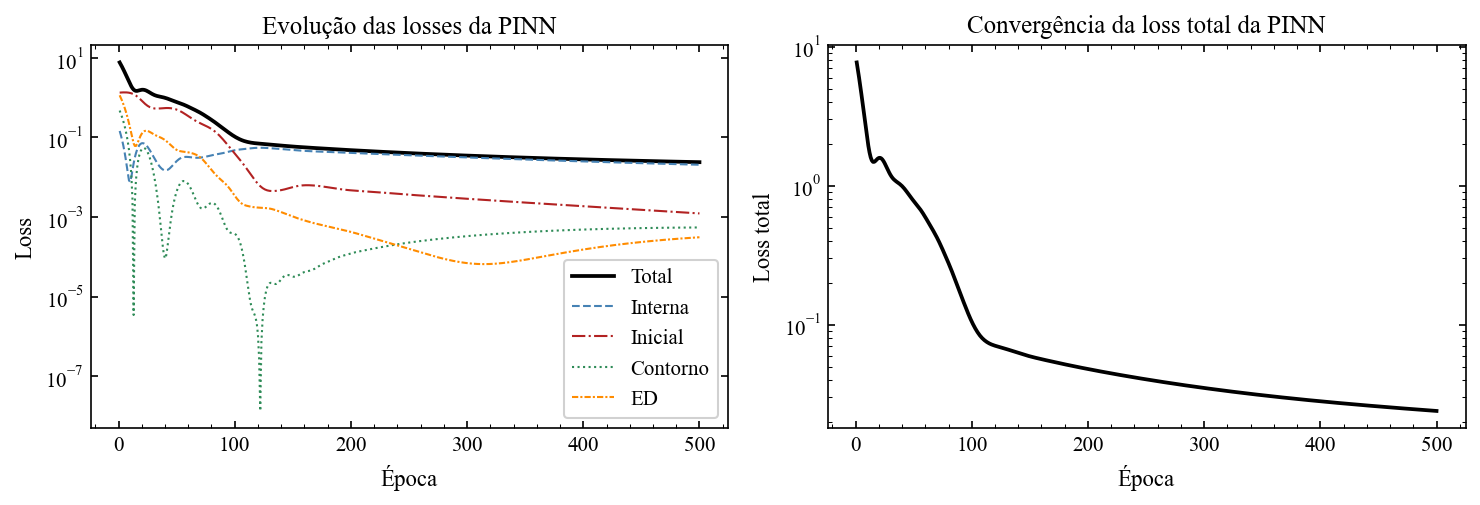

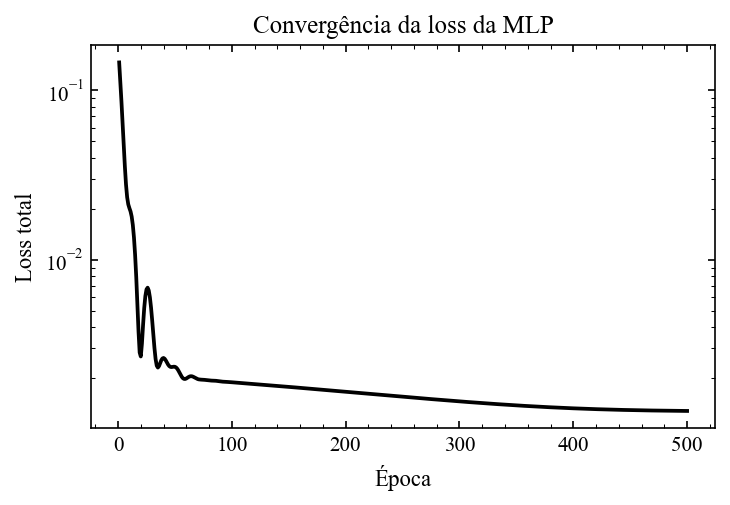

In [81]:
plot_losses(historico_pinn, nome_modelo='PINN', salvar=True, nome_arquivo='../Imagens/Resultados/Básico/losses_pinn_basica')
plot_losses(historico_mlp,  nome_modelo='MLP',  salvar=True, nome_arquivo='../Imagens/Resultados/Básico/losses_mlp_basica')

Abaixo estão os gráficos das perdas para os **modelos treinados com pontos equidistantes**.

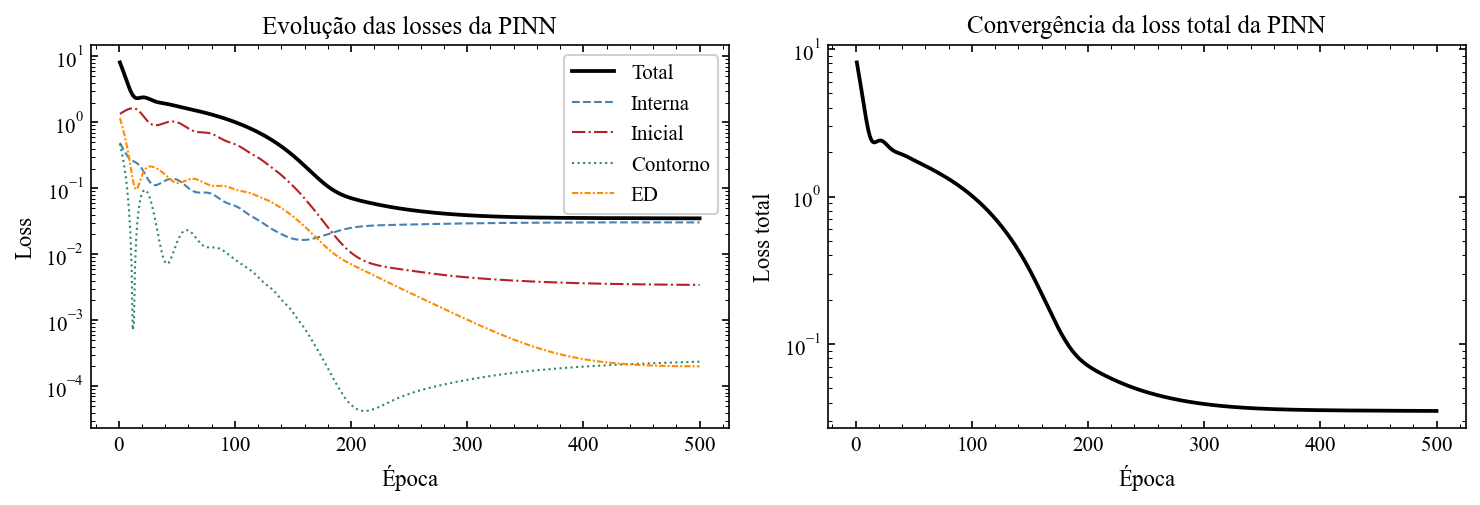

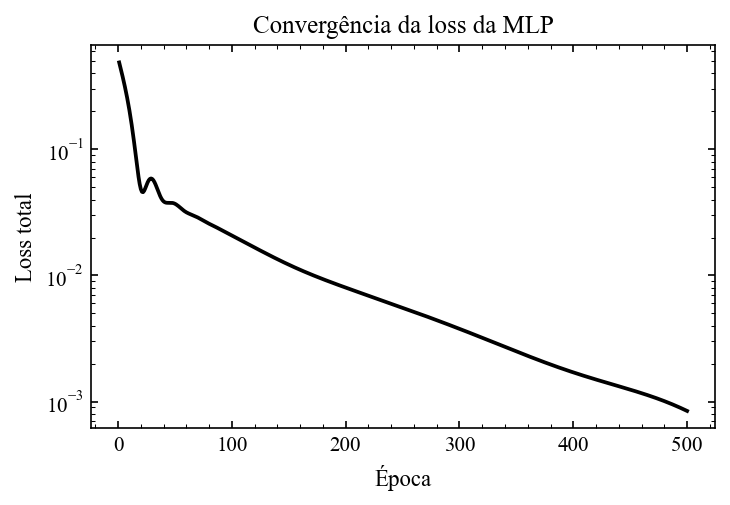

In [80]:
plot_losses(historico_pinn_eq, nome_modelo='PINN', salvar=True, nome_arquivo='../Imagens/Resultados/Básico/losses_pinn_eq_basica')
plot_losses(historico_mlp_eq,  nome_modelo='MLP',  salvar=True, nome_arquivo='../Imagens/Resultados/Básico/losses_mlp_eq_basica')

Note que é comum a função de perda da MLP ter valor menor que o da PINN, mas não se preocupe. Aqui a função perda é calculada no treino com os dados de treino, então é bem possível que isso seja devido a um *overfit* da MLP, pois estamos trabalhando com poucos pontos de colocação com ruído no valor de alvo (e distribuídos aleatoriamente para o primeiro dos conjuntos de gráficos).

### 6.8.2 Gráficos de solução: modelo X solução analítica

Abaixo são plotados gráficos de comparação com a solução analítica do problema. Para cada tipo de malha (pontos aleatórios ou equidistantes) são plotados os gráficos para dois intervalos de tempo diferentes: um deles vai até $t_{\mathrm{max}}$ e o outro até $2t_{\mathrm{max}}$ a fim de averiguar (visualmente) as capacidades de **interpolação** e **extrapolação** dos modelos, respectivamente.

# ############################################################### #
     Plots para malha de pontos aleatórios
# ############################################################### #
# --------------------------------------------- #
     Plots para limite máximo de t = 500.0
# --------------------------------------------- #


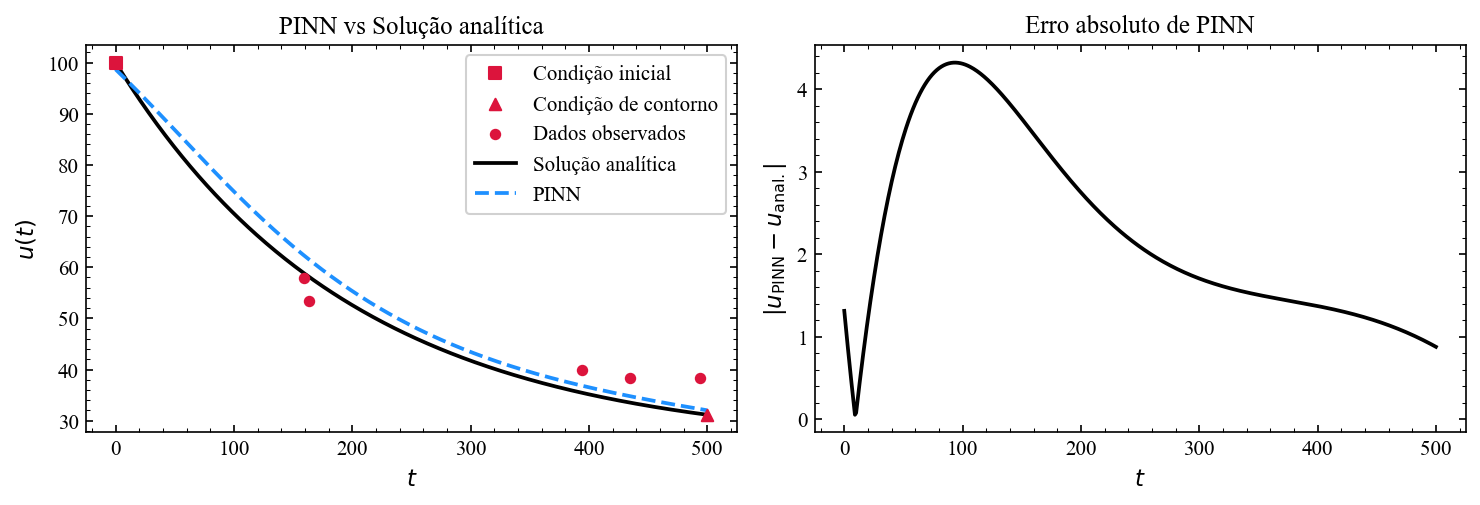

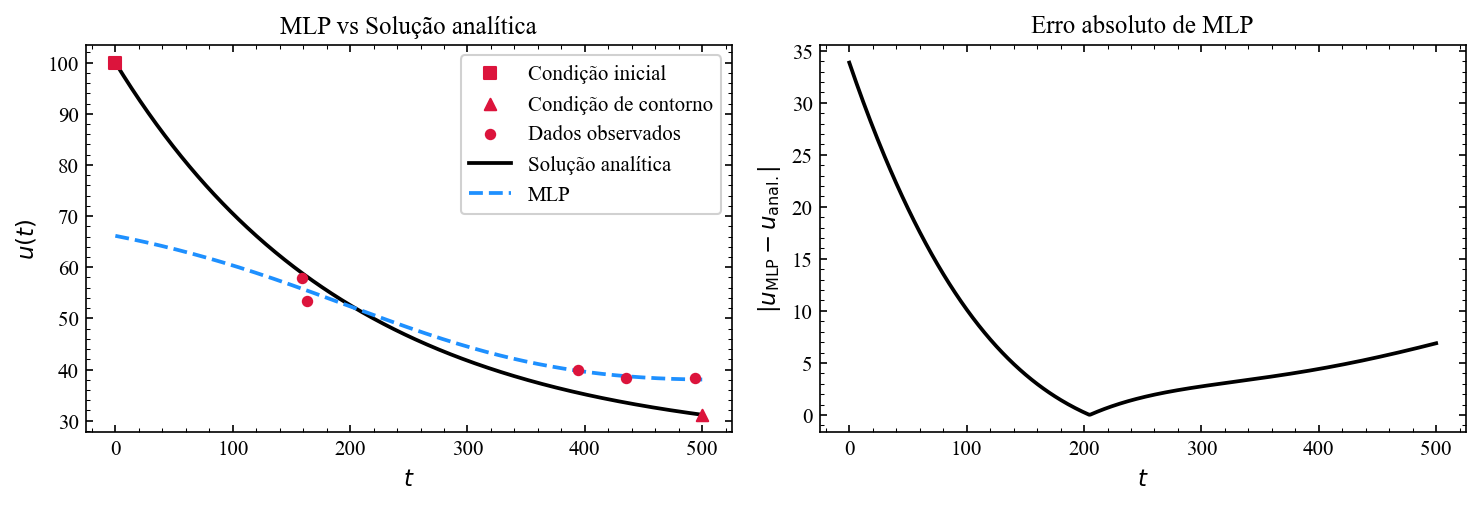

# --------------------------------------------- #
     Plots para limite máximo de t = 1000.0
# --------------------------------------------- #


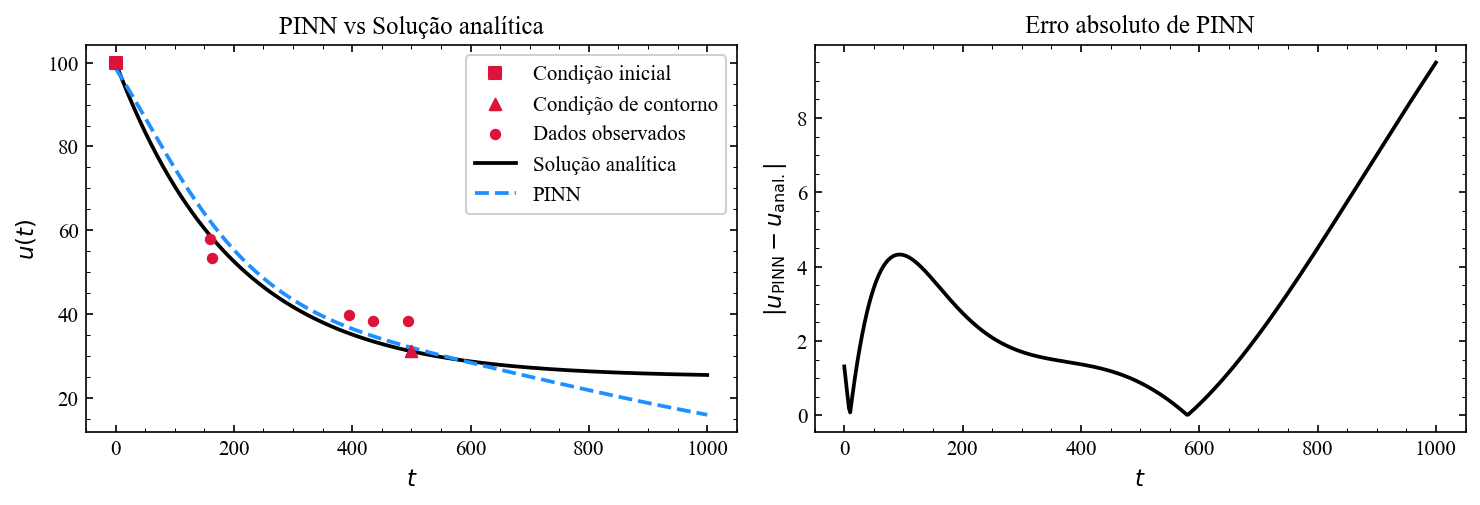

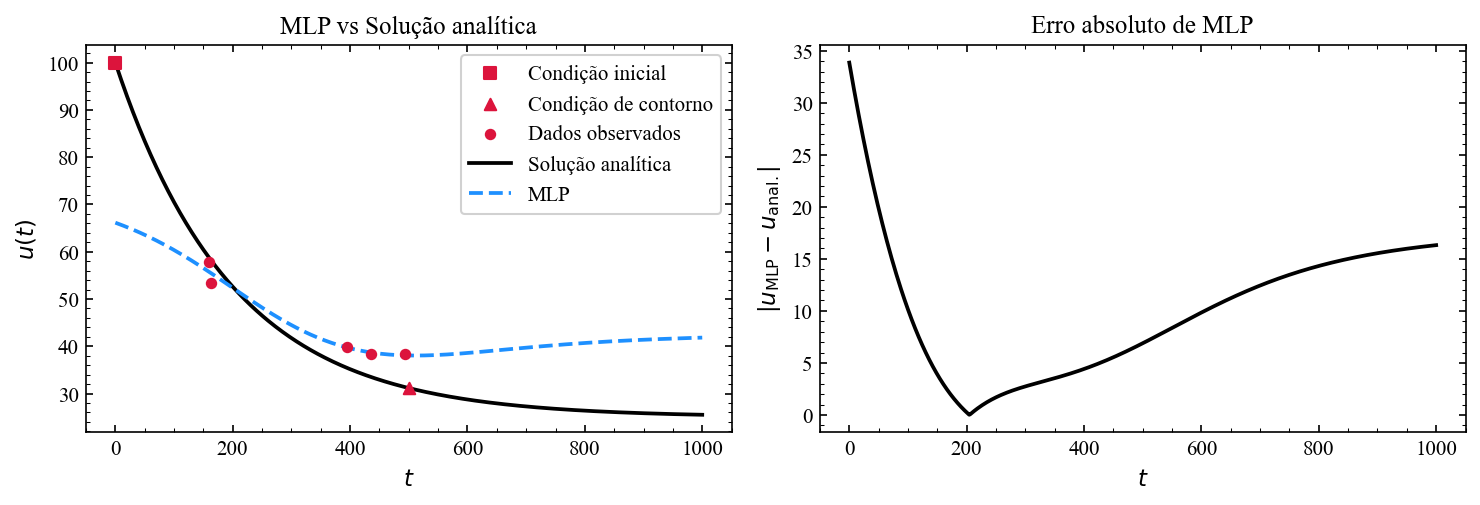

# ############################################################### #
     Plots para malha de pontos equidistantes
# ############################################################### #
# --------------------------------------------- #
     Plots para limite máximo de t = 500.0
# --------------------------------------------- #


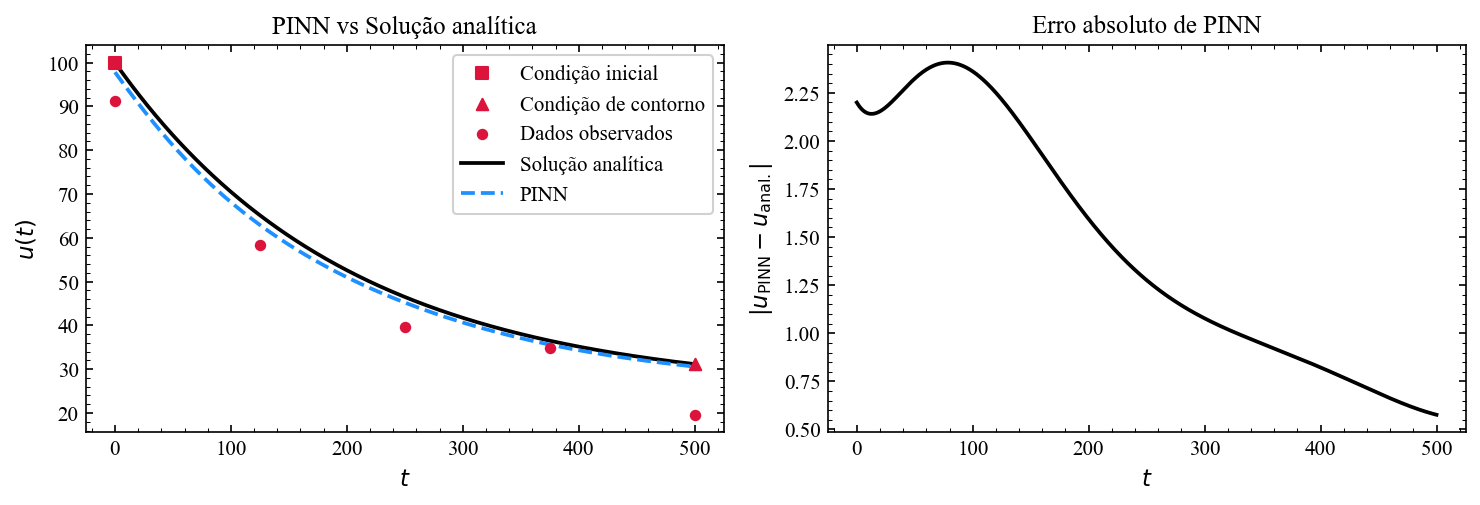

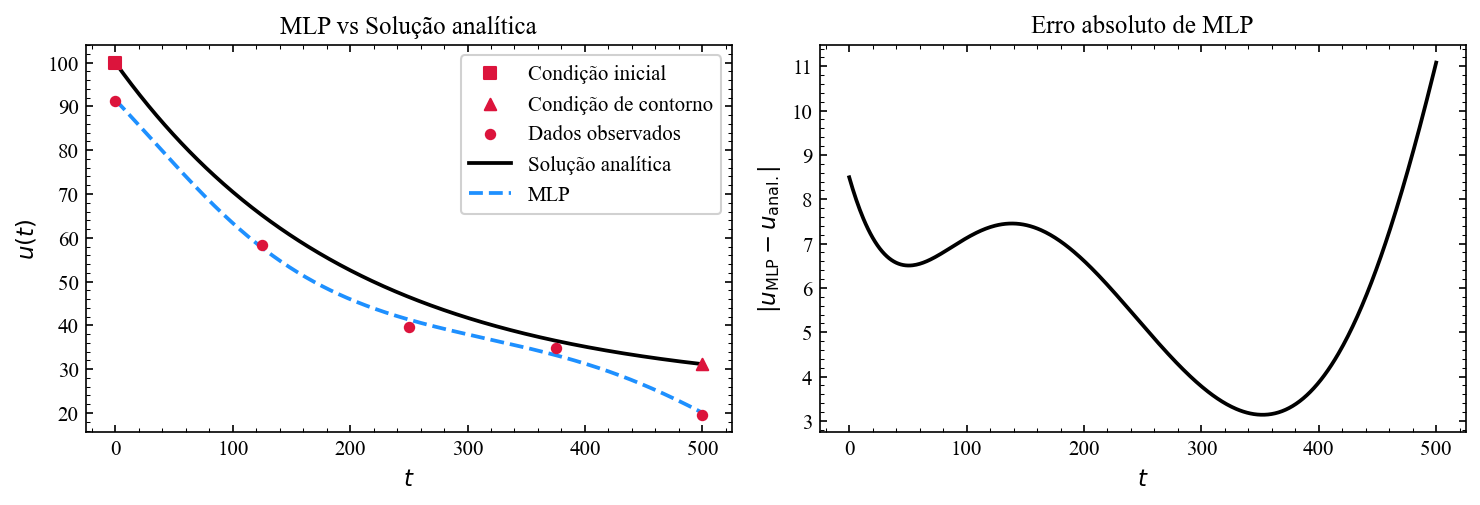

# --------------------------------------------- #
     Plots para limite máximo de t = 1000.0
# --------------------------------------------- #


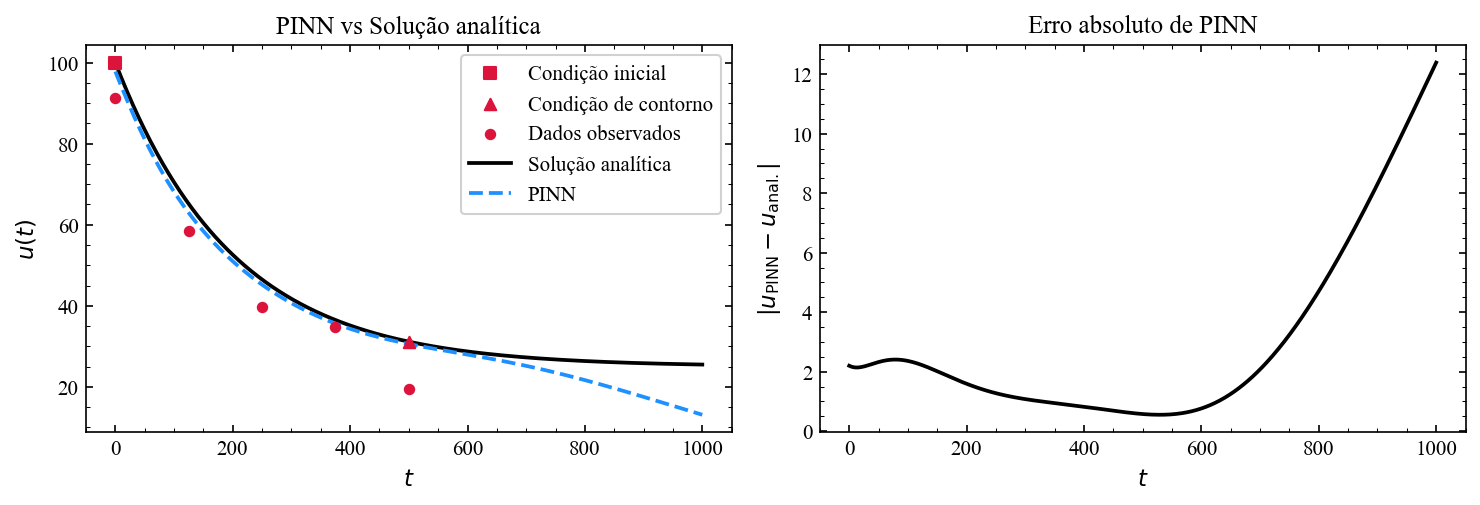

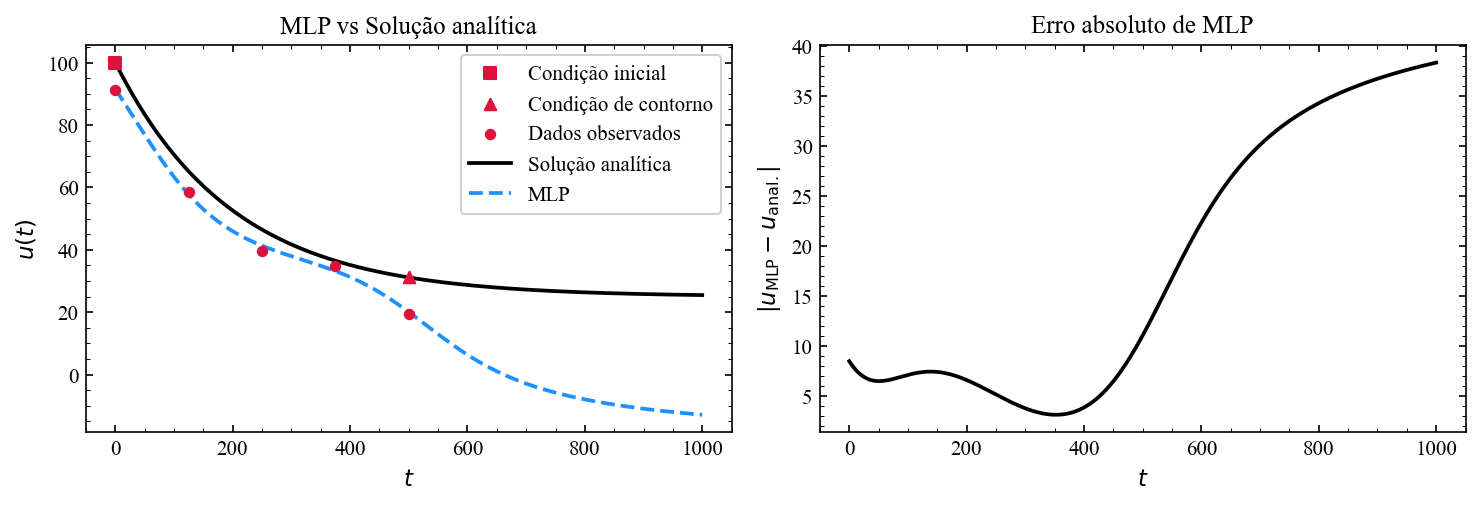

In [82]:
limite_t = [t_max, 2*t_max]
malhas = {"pontos aleatórios": (pinn, mlp, malha_interna, u_interno), 
          "pontos equidistantes": (pinn_eq, mlp_eq, malha_interna_eq, u_interno_eq)}

for malha in malhas:

    print('# ############################################################### #')
    print(f'     Plots para malha de {malha}')
    print('# ############################################################### #')
    
    for lim_t in limite_t:
    
        # Previsão PINN
        t_plot, u_pinn = prever(
            modelo=malhas[malha][0],
            t_min=t_min, 
            t_max=t_max, 
            t_min_prev=t_min, 
            t_max_prev=lim_t,   # limte máximo de t
            norm=True, 
            u_min=u_min, 
            u_max=u_max
        )

        # Previsão MLP
        _, u_mlp = prever(
            modelo=malhas[malha][1],
            t_min=t_min, 
            t_max=t_max, 
            t_min_prev=t_min, 
            t_max_prev=lim_t,   # limite máximo de t 
            norm=True, 
            u_min=u_min, 
            u_max=u_max
        )

        print('# --------------------------------------------- #')
        print(f'     Plots para limite máximo de t = {lim_t}')
        print('# --------------------------------------------- #')
    
        # Plot PINN
        plot_solucao(
            solucao_analitica=solucao_analitica_parcial,
            t_plot=t_plot,
            u_prev=u_pinn,
            malha_interna=malhas[malha][2],
            u_interno=malhas[malha][3],
            u_inicial=u_inicial,
            u_contorno=u_contorno,
            t_min=t_min,
            t_max=t_max,
            nome_modelo='PINN',
            norm=True,
            u_min=u_min,
            u_max=u_max,
            salvar=True,
            nome_arquivo=f'../Imagens/Resultados/Básico/solucao_pinn{"_eq" if malha == "pontos equidistantes" else ""}{"_1" if lim_t == t_max else "_2"}_basica'
        )

        # Plot MLP
        plot_solucao(
            solucao_analitica=solucao_analitica_parcial,
            t_plot=t_plot,
            u_prev=u_mlp,
            malha_interna=malhas[malha][2],
            u_interno=malhas[malha][3],
            u_inicial=u_inicial,
            u_contorno=u_contorno,
            t_min=t_min,
            t_max=t_max,
            nome_modelo='MLP',
            norm=True,
            u_min=u_min,
            u_max=u_max,
            salvar=True,
            nome_arquivo=f'../Imagens/Resultados/Básico/solucao_mlp{"_eq" if malha == "pontos equidistantes" else ""}{"_1" if lim_t == t_max else "_2"}_basica'
        )

## 6.9 Discussão de resultados

Observe que, apesar da MLP possuir uma loss menor que a PINN, os gráficos reforçam a idea de que a <b>MLP sofreu *overfit*</b> e apontam para que a PINN não, evidenciando a diferença crucial que considerar a Equação Diferencial como parte da função de perda faz para treino com poucos dados ruidosos. Observe também **a diferença que os pontos equidistantes fazem para a MLP** conseguir acompanhar o formato da solução analítica, enquanto a **PINN consegue acompanhá-la bem independentemente**.

A regularização da PINN via MSE do **resíduo da equação diferencial a força a seguir o comportamento esperado** na solução de decaimento exponencial, enquanto os **valores inicial** e de **contorno** ajudam a **"fixar" a solução particular** correta. A MLP, por não possuir nenhum desses termos extras na função de perda, sofre sobreajuste e foge completamente da solução esperada.

-------------------------

# 7. Conclusões

Vimos que as Redes Neurais Informadas por Física (do inglês *Physics Informed Neural Network*, PINN) são um tipo de rede neural voltado para a generalização do comportamento de dados regidos por equações diferenciais. **A principal diferença das PINNs para uma MLP está no uso do resíduo da equação diferencial** para adicionar um termo no cálculo da função de perda para regularização dela, limitando-a a seguir a dinâmica já conhecida do sistema. Mas não é a única diferença: considerar condição inicial e de contorno também faz uma grande diferença.

Montamos uma PINN passo a passo a partir de uma MLP e treinamos ambas redes num problema regido pela Lei de Resfriamento de Newton. Ao realizar o teste dos modelos, observamos que a PINN performou melhor que a MLP, que sofreu *overfit*, demonstrando **capacidade de generalização com poucos dados experimentais dispersos e ruidosos**.

-------------------------

# 8. Referências

[1] SCIKIT-LEARN. Neural networks (supervised). Disponível em: https://scikit-learn.org/stable/modules/neural_networks_supervised.html. Acesso em: 10 maio 2026.

[2] MOREIRA, Sandro. Rede Neural Perceptron Multicamadas. Ensina.AI, Medium, 2018. Disponível em: https://medium.com/ensina-ai/rede-neural-perceptron-multicamadas-f9de8471f1a9. Acesso em: 10 maio 2026.

[3] REN, Zhiyuan; ZHOU, Shijie; LIU, Dong; LIU, Qihe. Physics-Informed Neural Networks: a review of methodological evolution, theoretical foundations, and interdisciplinary frontiers toward next-generation scientific computing. Applied Sciences, Basel, MDPI, 2025. DOI: https://doi.org/10.3390/app15148092. Disponível em: https://www.mdpi.com/2076-3417/15/14/8092. Acesso em: 10 maio 2026.

[4] RAISSI, Maziar; PERDIKARIS, Paris; KARNIADAKIS, George Em. Physics-informed neural networks: a deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations. Journal of Computational Physics, v. 378, p. 686–707, fev. 2019. DOI: https://doi.org/10.1016/j.jcp.2018.10.045. Disponível em: https://www.sciencedirect.com/science/article/abs/pii/S0021999118307125. Acesso em: 10 maio 2026.

[5] WOLF, Theo. Physics-Informed Neural Networks: a simple tutorial with PyTorch. Medium, 2023. Disponível em: https://medium.com/@theo.wolf/physics-informed-neural-networks-a-simple-tutorial-with-pytorch-f28a890b874a. Acesso em: 10 maio 2026.

[6] NGUYEN, Khoa. pinns.py. GitHub, 2023. Disponível em: https://github.com/nguyenkhoa0209/pinns_tutorial/blob/main/pinns.py. Acesso em: 10 maio 2026.

------------------------

# 9. XKCD relevante

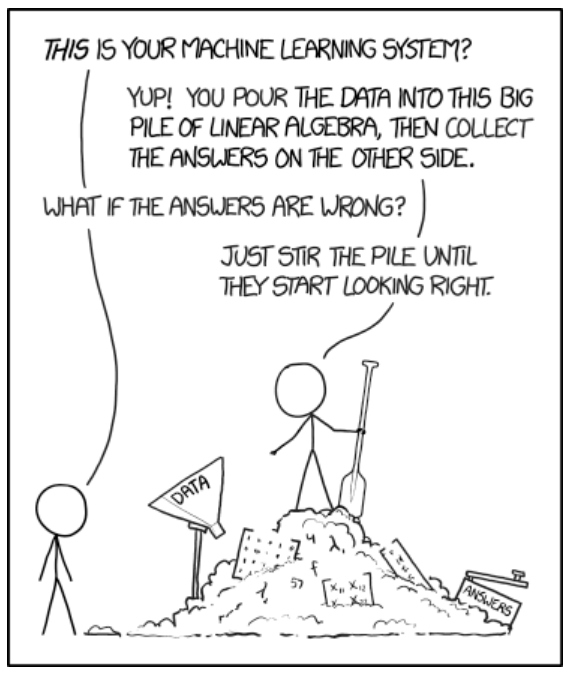

`Imagem: Machine Learning (XKCD). Disponível em: https://xkcd.com/1838/`